# Actividad práctica: Aprendizaje Automático con el dataset Iris

## Unidad 5 — Fundamentos en Ciencias de la Computación

---

### Objetivo de la actividad

En este notebook aplicaremos los conceptos vistos en clase sobre **aprendizaje supervisado** (clasificación y regresión) y **aprendizaje no supervisado** (clustering) usando un único conjunto de datos: el clásico dataset **Iris**.

El código está completamente escrito y listo para ejecutar. Tu tarea consiste en **ejecutar las celdas en orden, observar los resultados y responder las preguntas de interpretación** que aparecen en celdas marcadas como **Pregunta**.

### Cómo trabajar

1. Ejecutá las celdas de código de arriba hacia abajo, sin saltearlas.
2. Detenete en cada celda **Pregunta** y escribí tu respuesta en la celda **Tu respuesta** que sigue.
3. Las respuestas deben ser breves (3 a 6 líneas) pero conceptualmente sólidas. No copies definiciones de los slides: explicá con tus palabras lo que ves en los resultados.

### Sobre el dataset Iris

Iris contiene 150 mediciones de flores de tres especies distintas (_setosa_, _versicolor_ y _virginica_). Para cada flor se registraron cuatro medidas: largo y ancho del sépalo, y largo y ancho del pétalo. Es uno de los datasets más usados en la enseñanza del aprendizaje automático desde que Ronald Fisher lo publicó en 1936.


---

## 0. Preparación del entorno

Importamos las bibliotecas que vamos a usar a lo largo del notebook.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay,
    mean_squared_error, r2_score
)

# Semilla para reproducibilidad
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Estilo de los gráficos
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

print("Bibliotecas cargadas correctamente.")

Bibliotecas cargadas correctamente.


---

## 1. Carga y exploración de los datos

### El dato como punto de partida

Antes de pensar en modelos, conviene mirar el dato. Esto corresponde a las etapas iniciales del ciclo de vida del dato: comprensión, exploración y limpieza.

In [2]:
# Cargamos el dataset desde scikit-learn
iris = load_iris()

# Lo convertimos en un DataFrame de pandas para inspeccionarlo cómodamente
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["species"] = [iris.target_names[i] for i in iris.target]

print(f"Cantidad de instancias (filas): {df.shape[0]}")
print(f"Cantidad de features + label (columnas): {df.shape[1]}")
print(f"Nombres de las features: {iris.feature_names}")
print(f"Nombres de las clases: {list(iris.target_names)}")
df.head()

Cantidad de instancias (filas): 150
Cantidad de features + label (columnas): 5
Nombres de las features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Nombres de las clases: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
# Estadísticas descriptivas por especie
df.groupby("species").describe().T

species                     setosa  versicolor  virginica
sepal length (cm) count  50.000000   50.000000  50.000000
                  mean    5.006000    5.936000   6.588000
                  std     0.352490    0.516171   0.635880
                  min     4.300000    4.900000   4.900000
                  25%     4.800000    5.600000   6.225000
                  50%     5.000000    5.900000   6.500000
                  75%     5.200000    6.300000   6.900000
                  max     5.800000    7.000000   7.900000
sepal width (cm)  count  50.000000   50.000000  50.000000
                  mean    3.428000    2.770000   2.974000
                  std     0.379064    0.313798   0.322497
                  min     2.300000    2.000000   2.200000
                  25%     3.200000    2.525000   2.800000
                  50%     3.400000    2.800000   3.000000
                  75%     3.675000    3.000000   3.175000
                  max     4.400000    3.400000   3.800000
petal length (cm) count  50.000000   50.000000  50.000000
                  mean    1.462000    4.260000   5.552000
                  std     0.173664    0.469911   0.551895
                  min     1.000000    3.000000   4.500000
                  25%     1.400000    4.000000   5.100000
                  50%     1.500000    4.350000   5.550000
                  75%     1.575000    4.600000   5.875000
                  max     1.900000    5.100000   6.900000
petal width (cm)  count  50.000000   50.000000  50.000000
                  mean    0.246000    1.326000   2.026000
                  std     0.105386    0.197753   0.274650
                  min     0.100000    1.000000   1.400000
                  25%     0.200000    1.200000   1.800000
                  50%     0.200000    1.300000   2.000000
                  75%     0.300000    1.500000   2.300000
                  max     0.600000    1.800000   2.500000

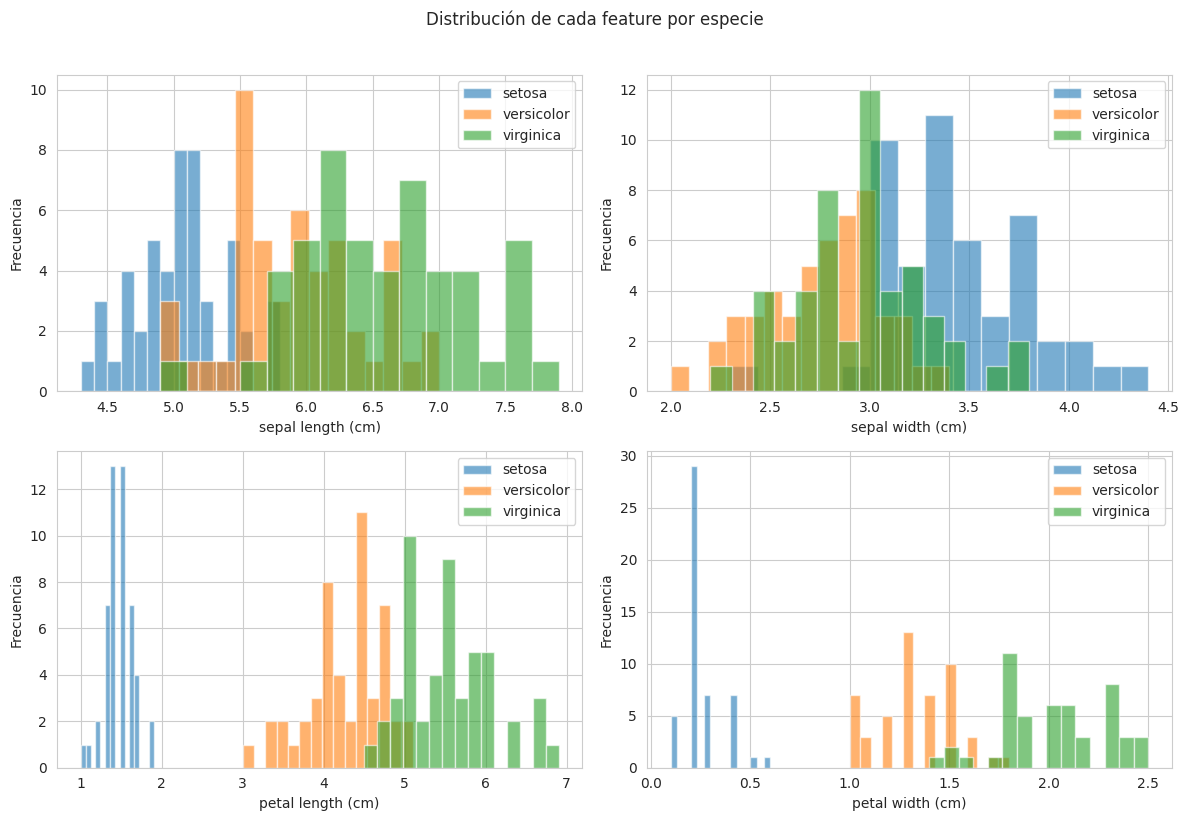

In [4]:
# Visualización: distribución de cada feature por especie
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for i, feature in enumerate(iris.feature_names):
    ax = axes[i // 2, i % 2]
    for species in iris.target_names:
        subset = df[df["species"] == species][feature]
        ax.hist(subset, alpha=0.6, label=species, bins=15)
    ax.set_xlabel(feature)
    ax.set_ylabel("Frecuencia")
    ax.legend()
plt.suptitle("Distribución de cada feature por especie", y=1.02)
plt.tight_layout()
plt.show()

### Pregunta 1

Observando los histogramas, ¿qué features parecen más útiles para distinguir entre las tres especies? ¿Por qué? Justificá tu respuesta refiriéndote al grado de **superposición** entre las distribuciones de cada especie.

**Tu respuesta:**

_Escribí acá tu respuesta._

---

## 2. Identificando instancias, features y label

Vamos a separar explícitamente lo que en clase llamamos **X** (matriz de features) y **y** (vector de labels). Esta separación es el primer paso de todo proyecto supervisado.

In [5]:
# X contiene las features (variables de entrada)
X = df[iris.feature_names].values

# y contiene el label (variable de salida que queremos predecir)
y = iris.target  # 0=setosa, 1=versicolor, 2=virginica

print(f"Shape de X: {X.shape}  (instancias x features)")
print(f"Shape de y: {y.shape}  (instancias)")
print()
print(f"Primeras 3 instancias de X:")
print(X[:3])
print()
print(f"Primeros 3 labels de y: {y[:3]}")

Shape de X: (150, 4)  (instancias x features)
Shape de y: (150,)  (instancias)

Primeras 3 instancias de X:
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]]

Primeros 3 labels de y: [0 0 0]


### Pregunta 2

A partir de la salida anterior, respondé en una o dos líneas cada una:

a) ¿Cuántas **instancias** tiene el dataset?

b) ¿Cuántas **features** tiene cada instancia?

c) ¿Cuál es la **dimensionalidad** del espacio donde viven nuestros datos?

d) ¿Qué representa cada valor del vector `y`?

**Tu respuesta:**

_Escribí acá tu respuesta._

---

## 3. División de los datos: entrenamiento y prueba

Para evaluar honestamente la capacidad de generalización del modelo, separamos los datos en dos conjuntos. Por simplicidad usamos solo train y test (sin validación), pero conviene recordar que en proyectos reales se usan los tres conjuntos.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,         # 30% para test, 70% para train
    random_state=RANDOM_STATE,
    stratify=y             # mantenemos la proporción de clases en ambos conjuntos
)

print(f"Conjunto de entrenamiento: {X_train.shape[0]} instancias")
print(f"Conjunto de prueba: {X_test.shape[0]} instancias")
print()
print("Distribución de clases en train:")
print(pd.Series(y_train).map(lambda i: iris.target_names[i]).value_counts())
print()
print("Distribución de clases en test:")
print(pd.Series(y_test).map(lambda i: iris.target_names[i]).value_counts())

Conjunto de entrenamiento: 105 instancias
Conjunto de prueba: 45 instancias

Distribución de clases en train:
versicolor    35
setosa        35
virginica     35
Name: count, dtype: int64

Distribución de clases en test:
virginica     15
versicolor    15
setosa        15
Name: count, dtype: int64


### Pregunta 3

a) ¿Por qué dividimos los datos en lugar de entrenar y evaluar sobre el conjunto completo? Pensá en qué pasaría si evaluamos al modelo sobre los mismos datos con los que aprendió.

b) El parámetro `stratify=y` hace que la proporción de clases sea la misma en train y test. ¿Por qué puede ser importante esto? ¿Qué problema podría ocurrir si una clase quedara solo en train y no en test?

**Tu respuesta:**

_Escribí acá tu respuesta._

---

## 4. Aprendizaje supervisado: clasificación

Entrenamos un clasificador para predecir la especie a partir de las cuatro medidas. Usaremos **regresión logística**, uno de los modelos clásicos de clasificación.

In [7]:
# Estandarizamos las features (importante para modelos lineales)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Entrenamos el modelo
clf = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
clf.fit(X_train_scaled, y_train)

# Predicciones
y_pred_train = clf.predict(X_train_scaled)
y_pred_test = clf.predict(X_test_scaled)

print("Modelo entrenado.")
print(f"Parámetros aprendidos (coeficientes): shape {clf.coef_.shape}")
print(f"Total de parámetros del modelo: {clf.coef_.size + clf.intercept_.size}")

Modelo entrenado.
Parámetros aprendidos (coeficientes): shape (3, 4)
Total de parámetros del modelo: 15


### Pregunta 4

El modelo tiene un número finito de parámetros internos (los coeficientes y el intercepto). Conectá esto con la fórmula vista en clase: **y = f(x; θ)**.

a) ¿Qué juega el rol de **θ** en este modelo?

b) ¿Qué juega el rol de **f**?

c) Durante el entrenamiento, ¿qué se ajusta: f, θ, o ambos?

**Tu respuesta:**

_Escribí acá tu respuesta._

In [8]:
# Evaluación: accuracy en train y test
acc_train = accuracy_score(y_train, y_pred_train)
acc_test = accuracy_score(y_test, y_pred_test)

print(f"Accuracy en TRAIN: {acc_train:.4f}")
print(f"Accuracy en TEST:  {acc_test:.4f}")

Accuracy en TRAIN: 0.9810
Accuracy en TEST:  0.9111


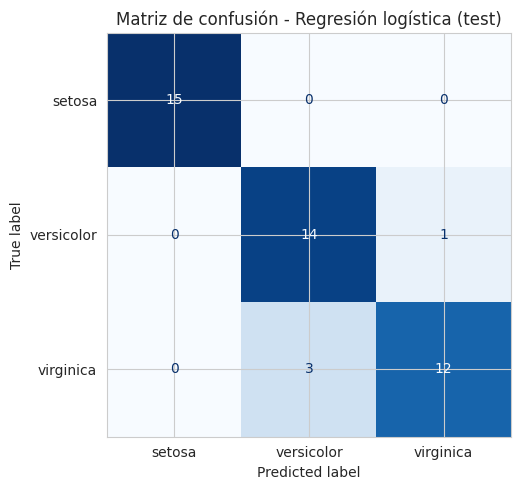

In [9]:
# Matriz de confusión sobre el conjunto de test
cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Matriz de confusión - Regresión logística (test)")
plt.tight_layout()
plt.show()

In [10]:
# Métricas adicionales: precision y recall por clase
print("Métricas por clase (sobre test):")
print()
for i, name in enumerate(iris.target_names):
    # Para cada clase, calculamos precision y recall tratándola como "positiva"
    prec = precision_score(y_test, y_pred_test, labels=[i], average="macro", zero_division=0)
    rec = recall_score(y_test, y_pred_test, labels=[i], average="macro", zero_division=0)
    print(f"  {name:12s}  precision={prec:.3f}   recall={rec:.3f}")

Métricas por clase (sobre test):

  setosa        precision=1.000   recall=1.000
  versicolor    precision=0.824   recall=0.933
  virginica     precision=0.923   recall=0.800


### Pregunta 5

a) Comparando accuracy en train y en test, ¿el modelo parece estar **sobreajustando** (overfitting), **subajustando** (underfitting), o ajustando correctamente? Justificá.

b) Mirando la matriz de confusión, ¿hay alguna especie que sea más difícil de clasificar que las otras? ¿Con cuál se confunde? Conectá esto con tu respuesta a la Pregunta 1: ¿tiene sentido?

**Tu respuesta:**

_Escribí acá tu respuesta._

---

## 5. El compromiso entre sesgo y varianza

Vamos a comparar tres árboles de decisión con distinta **complejidad** (profundidad máxima) para ver el compromiso entre sesgo y varianza en acción.

In [11]:
profundidades = [1, 3, 10]
resultados = []

for d in profundidades:
    tree = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE)
    tree.fit(X_train, y_train)
    acc_tr = accuracy_score(y_train, tree.predict(X_train))
    acc_te = accuracy_score(y_test, tree.predict(X_test))
    resultados.append({
        "max_depth": d,
        "accuracy_train": acc_tr,
        "accuracy_test": acc_te,
        "diferencia": acc_tr - acc_te
    })

resultados_df = pd.DataFrame(resultados)
print(resultados_df.to_string(index=False))

 max_depth  accuracy_train  accuracy_test  diferencia
         1        0.666667       0.666667    0.000000
         3        0.980952       0.977778    0.003175
        10        1.000000       0.933333    0.066667


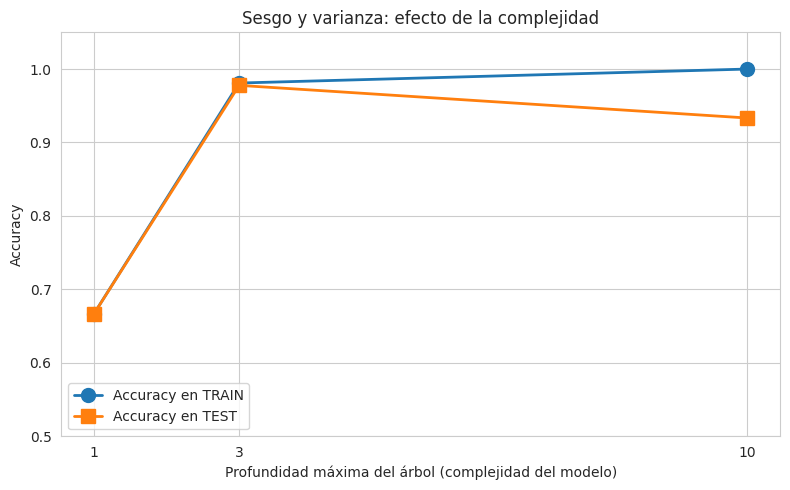

In [12]:
# Visualización del compromiso
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(resultados_df["max_depth"], resultados_df["accuracy_train"],
        "o-", label="Accuracy en TRAIN", linewidth=2, markersize=10)
ax.plot(resultados_df["max_depth"], resultados_df["accuracy_test"],
        "s-", label="Accuracy en TEST", linewidth=2, markersize=10)
ax.set_xlabel("Profundidad máxima del árbol (complejidad del modelo)")
ax.set_ylabel("Accuracy")
ax.set_title("Sesgo y varianza: efecto de la complejidad")
ax.set_xticks(profundidades)
ax.legend()
ax.set_ylim(0.5, 1.05)
plt.tight_layout()
plt.show()

### Pregunta 6

a) ¿Cuál de los tres árboles parece tener **alto sesgo** (underfitting)? ¿Cómo lo identificás?

b) ¿Cuál parece tener **alta varianza** (overfitting)? ¿Qué señal te lo indica?

c) Si tuvieras que elegir uno de los tres para usar en producción, ¿cuál elegirías y por qué?

d) Pensando en el ciclo del compromiso sesgo-varianza visto en clase, ¿qué pasaría si probáramos `max_depth=100`? ¿Y si probáramos `max_depth=1` pero con muchas más features irrelevantes?

**Tu respuesta:**

_Escribí acá tu respuesta._

---

## 6. Aprendizaje supervisado: regresión

Reusamos el mismo dataset pero cambiamos el problema. Ahora vamos a **predecir el largo del pétalo** (`petal length (cm)`) a partir de las otras tres medidas. El target deja de ser una etiqueta categórica y pasa a ser un valor continuo.

In [13]:
# Reformulamos el problema: largo del pétalo como target continuo
feature_names_reg = ["sepal length (cm)", "sepal width (cm)", "petal width (cm)"]
X_reg = df[feature_names_reg].values
y_reg = df["petal length (cm)"].values

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.3, random_state=RANDOM_STATE
)

# Entrenamos una regresión lineal
reg = LinearRegression()
reg.fit(X_reg_train, y_reg_train)

y_reg_pred = reg.predict(X_reg_test)

mse = mean_squared_error(y_reg_test, y_reg_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_reg_test, y_reg_pred)

print(f"MSE (error cuadrático medio): {mse:.4f}")
print(f"RMSE (en las unidades del target, cm): {rmse:.4f}")
print(f"R² (coeficiente de determinación): {r2:.4f}")
print()
print(f"Coeficientes aprendidos:")
for fname, coef in zip(feature_names_reg, reg.coef_):
    print(f"  {fname:25s}  {coef:+.4f}")
print(f"  {'intercepto':25s}  {reg.intercept_:+.4f}")

MSE (error cuadrático medio): 0.1091
RMSE (en las unidades del target, cm): 0.3303
R² (coeficiente de determinación): 0.9676

Coeficientes aprendidos:
  sepal length (cm)          +0.7452
  sepal width (cm)           -0.6517
  petal width (cm)           +1.4538
  intercepto                 -0.3238


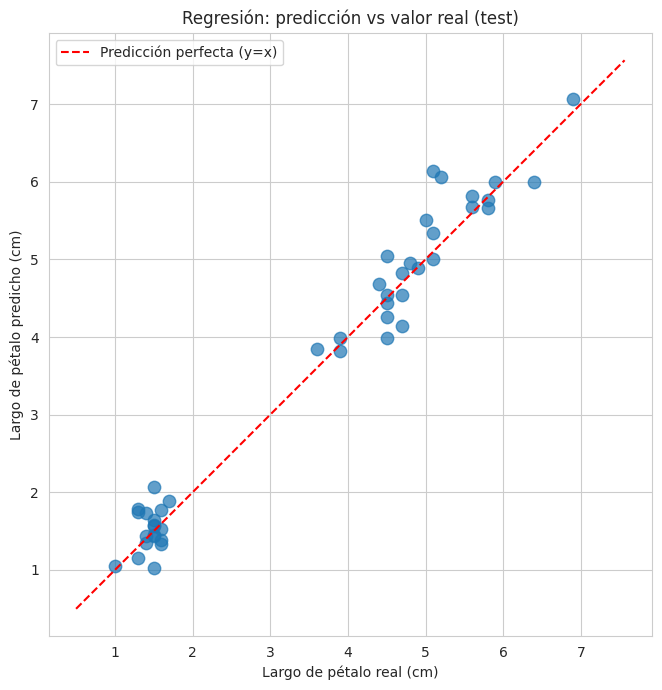

In [14]:
# Visualización: predicciones vs valores reales
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_reg_test, y_reg_pred, alpha=0.7, s=80)
lims = [min(y_reg_test.min(), y_reg_pred.min()) - 0.5,
        max(y_reg_test.max(), y_reg_pred.max()) + 0.5]
ax.plot(lims, lims, "r--", label="Predicción perfecta (y=x)")
ax.set_xlabel("Largo de pétalo real (cm)")
ax.set_ylabel("Largo de pétalo predicho (cm)")
ax.set_title("Regresión: predicción vs valor real (test)")
ax.legend()
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

### Pregunta 7

a) ¿Por qué este problema es una **regresión** y no una clasificación? ¿Qué cambió respecto del problema anterior?

b) El R² obtenido es muy alto (cercano a 1). ¿Qué te dice esto sobre la relación entre las features y el target? ¿Sería razonable esperar un R² similar al intentar predecir, por ejemplo, el precio de una vivienda a partir de su superficie? ¿Por qué sí o por qué no?

c) Mirando los coeficientes, ¿qué feature parece tener mayor influencia sobre la predicción del largo de pétalo? **Atención:** ¿podemos comparar coeficientes directamente cuando las features están en distintas escalas?

**Tu respuesta:**

_Escribí acá tu respuesta._

---

## 7. Aprendizaje no supervisado: clustering

Ahora vamos a hacer un experimento crucial: vamos a **ignorar las etiquetas** y aplicar K-Means para ver si el algoritmo, sin saber qué es cada flor, descubre por sí mismo los grupos naturales en los datos.

Esto es aprendizaje **no supervisado**: el modelo recibe solo X, nunca y.

In [15]:
# Estandarizamos (importante para K-Means porque usa distancias)
X_scaled = StandardScaler().fit_transform(X)

# Aplicamos K-Means con k=3 (sabemos que hay 3 especies, pero el algoritmo no lo sabe)
kmeans = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

print(f"Etiquetas reales (primeras 20):    {y[:20]}")
print(f"Clusters asignados (primeros 20):  {clusters[:20]}")
print()
print("Atención: los números de cluster (0, 1, 2) son arbitrarios.")
print("K-Means no sabe cuál cluster corresponde a setosa, versicolor o virginica.")

Etiquetas reales (primeras 20):    [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Clusters asignados (primeros 20):  [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]

Atención: los números de cluster (0, 1, 2) son arbitrarios.
K-Means no sabe cuál cluster corresponde a setosa, versicolor o virginica.


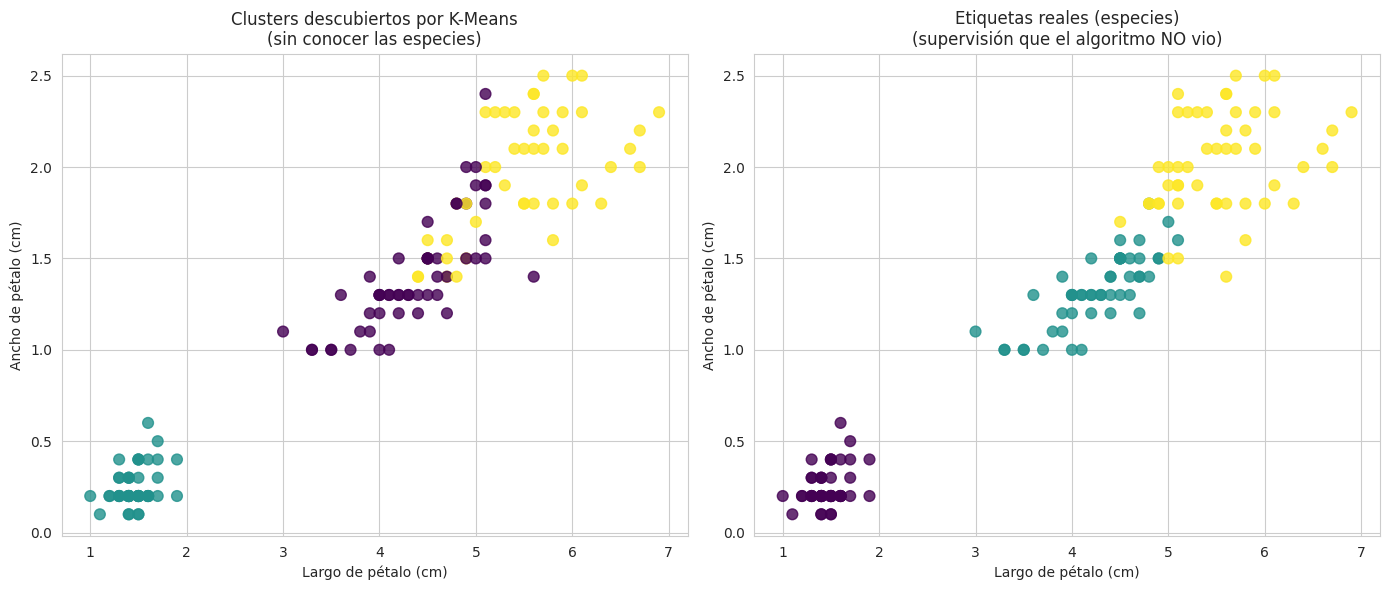

In [16]:
# Comparación visual: clusters descubiertos vs etiquetas reales
# Usamos las dos features más informativas para visualizar en 2D
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel izquierdo: clusters descubiertos por K-Means
scatter1 = axes[0].scatter(X[:, 2], X[:, 3], c=clusters, cmap="viridis", s=60, alpha=0.8)
axes[0].set_xlabel("Largo de pétalo (cm)")
axes[0].set_ylabel("Ancho de pétalo (cm)")
axes[0].set_title("Clusters descubiertos por K-Means\n(sin conocer las especies)")

# Panel derecho: etiquetas reales
scatter2 = axes[1].scatter(X[:, 2], X[:, 3], c=y, cmap="viridis", s=60, alpha=0.8)
axes[1].set_xlabel("Largo de pétalo (cm)")
axes[1].set_ylabel("Ancho de pétalo (cm)")
axes[1].set_title("Etiquetas reales (especies)\n(supervisión que el algoritmo NO vio)")

plt.tight_layout()
plt.show()

In [17]:
# Tabla de contingencia: ¿qué tanto se parecen clusters y etiquetas reales?
contingencia = pd.crosstab(
    pd.Series([iris.target_names[i] for i in y], name="Especie real"),
    pd.Series(clusters, name="Cluster descubierto")
)
print("Tabla de contingencia:")
print(contingencia)

Tabla de contingencia:
Cluster descubierto   0   1   2
Especie real                   
setosa                0  50   0
versicolor           39   0  11
virginica            14   0  36


### Pregunta 8

a) Comparando los dos paneles del gráfico, ¿K-Means logró recuperar la estructura de las tres especies sin haber visto las etiquetas? ¿Perfectamente o con errores?

b) Mirando la tabla de contingencia, ¿hay alguna especie que K-Means haya separado limpiamente del resto? ¿Y alguna donde el algoritmo se haya confundido más?

c) Conceptualmente: ¿qué significa que un algoritmo **no supervisado** logre recuperar una estructura que existe en los datos sin haber recibido etiquetas? ¿Qué hubiera pasado si las especies de Iris se diferenciaran solo por una característica que no medimos?

**Tu respuesta:**

_Escribí acá tu respuesta._

---

## 8. Síntesis integradora

### Pregunta 9 (síntesis)

A lo largo del notebook usamos el **mismo dataset Iris** para resolver tres problemas distintos:

| Sección | Problema | Paradigma | Tipo de target |
|---------|----------|-----------|----------------|
| 4 | Predecir especie | ? | ? |
| 6 | Predecir largo de pétalo | ? | ? |
| 7 | Descubrir grupos naturales | ? | ? |

Completá la tabla en tu respuesta indicando, para cada problema:

a) Si es **supervisado** o **no supervisado**.

b) Si el target es **categórico (discreto)**, **continuo**, o si **no hay target**.

c) Para los problemas supervisados, si es **clasificación** o **regresión**.

**Tu respuesta:**

_Escribí acá tu respuesta._

### Pregunta 10 (reflexión crítica)

El dataset Iris es un caso casi ideal: tiene pocas features, sin valores faltantes, balanceado entre clases y con un fenómeno biológico real detrás que hace que los grupos sean genuinamente distinguibles. Esto explica por qué los modelos funcionan tan bien.

Pensá en un **problema realista de tu entorno** (puede ser de la industria, de la salud, de la educación, de tu propia carrera) y reflexioná:

a) ¿Cómo te imaginás que serían los datos? Mencioná al menos dos problemas concretos que probablemente tendrías que enfrentar en la etapa de limpieza y exploración (etapas 3 y 4 del ciclo del dato).

b) ¿Esperarías obtener un desempeño tan alto como el que vimos con Iris? ¿Por qué sí o por qué no?

c) Mencioná al menos una **limitación estructural** (ruido, sesgo o varianza) que considerás especialmente relevante para tu problema, y explicá por qué.

**Tu respuesta:**

_Escribí acá tu respuesta._

---

## Cierre

Si llegaste hasta acá habiendo respondido todas las preguntas, ya manejás los conceptos básicos del aprendizaje automático aplicados a un caso concreto. En las próximas clases vamos a profundizar en redes neuronales y modelos generativos, y muchas de las ideas que viste hoy (división de los datos, métricas de evaluación, compromiso sesgo-varianza) van a reaparecer en esos contextos más complejos.

**Entrega:** guardá este notebook con tus respuestas en formato `.ipynb` y subilo a la plataforma del curso.
